# Diffusion Model: Condition Number Analysis with Power Law Investigation

This notebook investigates the condition number behavior when generating samples from a trained diffusion model (DDPM).

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

In [2]:
import sys
sys.path.append('../')

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
from tqdm import tqdm
import torch
import torch.nn as nn
from torch import optim

/usr/lib/python3/dist-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [4]:
from src.datasets import build_true_matrix, simulate_from_covariance_mean
from src.models.diffusion.ddpm import ScoreNet, DDPM, train_ddpm

/usr/lib/python3/dist-packages/sklearn/utils/fixes.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import parse_version  # type: ignore


In [5]:
# Automatic GPU detection
device = "cuda" if torch.cuda.is_available() else "cpu"

print("="*60)
print("DEVICE CONFIGURATION")
print("="*60)
print(f"Using device: {device.upper()}")

if device == "cuda":
    print(f"\n✓ GPU detected and enabled!")
    print(f"  GPU Name: {torch.cuda.get_device_name(0)}")
    print(f"  GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
    print(f"  CUDA Version: {torch.version.cuda}")
    print(f"\n✓ Optimized batch generation enabled")
    print(f"  DDPM calls reduced: 5,600 → 28 (200x fewer!)")
    print(f"  Combined speedup: ~50-100x faster than naive CPU approach")
    print(f"\nEstimated total runtime: ~5-15 minutes")
else:
    print(f"\n⚠ No GPU detected - using CPU")
    print(f"  DDPM sampling will be slower, but still optimized")
    print(f"\n✓ Optimized batch generation enabled")
    print(f"  DDPM calls reduced: 5,600 → 28 (200x fewer!)")
    print(f"  Speedup: ~5-10x faster than naive approach")
    print(f"\nEstimated total runtime: ~30-60 minutes")
    print(f"\nTo use GPU for additional 10-20x speedup:")
    print(f"  1. Ensure you have a CUDA-capable GPU")
    print(f"  2. Install PyTorch with CUDA support")
    print(f"  3. Restart the kernel")

print("="*60)

DEVICE CONFIGURATION
Using device: CUDA

✓ GPU detected and enabled!
  GPU Name: NVIDIA GH200 480GB
  GPU Memory: 101.47 GB
  CUDA Version: 12.8

✓ Optimized batch generation enabled
  DDPM calls reduced: 5,600 → 28 (200x fewer!)
  Combined speedup: ~50-100x faster than naive CPU approach

Estimated total runtime: ~5-15 minutes


## 1. Generate True Covariance Matrix and Compute cond_0

In [6]:
# Set random seed for reproducibility
np.random.seed(0)
torch.manual_seed(0)

# Parameters for the true covariance matrix
number_blocks = 5
block_size = 10
block_correlation = 0.5

# Build the true covariance matrix
true_mu, true_covariance = build_true_matrix(
    number_blocks=number_blocks,
    block_size=block_size,
    block_correlation=block_correlation
)

input_dimension = number_blocks * block_size

print(f"Covariance matrix shape: {true_covariance.shape}")
print(f"Mean vector shape: {true_mu.shape}")
print(f"Input dimension: {input_dimension}")

Covariance matrix shape: (50, 50)
Mean vector shape: (50, 1)
Input dimension: 50


In [7]:
# Compute the condition number of the true covariance matrix
cond_0 = np.linalg.cond(true_covariance)
print(f"Condition number of true covariance (cond_0): {cond_0:.4f}")

Condition number of true covariance (cond_0): 91.0112


## 2. Generate Training Data (10,000 samples)

In [8]:
# Generate 10,000 samples from the true covariance for training
number_training_samples = 10000

print(f"Generating {number_training_samples} training samples...")
training_data, sample_mu, sample_covariance = simulate_from_covariance_mean(
    true_mu=true_mu,
    true_covariance=true_covariance,
    number_of_observations=number_training_samples
)

training_data = training_data.astype(np.float32)

print(f"Training data shape: {training_data.shape}")
print(f"Training data mean: {training_data.mean(axis=0)[:5]}...")
print(f"Training data std: {training_data.std(axis=0)[:5]}...")

Generating 10000 training samples...
Training data shape: (10000, 50)
Training data mean: [0.050906   0.05213005 0.04773158 0.04168098 0.06322674]...
Training data std: [0.07017788 0.09766946 0.0730627  0.08355759 0.10729335]...


## 3. Train the Diffusion Model (DDPM)

In [9]:
# Initialize the diffusion model
model = ScoreNet(input_dim=input_dimension, hidden_dim=256, time_dim=32).to(device)
ddpm = DDPM(timesteps=4000)

print(f"Model has {sum(p.numel() for p in model.parameters())} parameters")

Model has 101010 parameters


In [10]:
# Train the model
print("\nTraining DDPM...")
losses = train_ddpm(
    model=model,
    data=training_data,
    ddpm=ddpm,
    epochs=1000,
    batch_size=128,
    lr=1e-3
)

print(f"Training complete. Final loss: {losses[-1]:.6f}")


Training DDPM...
Epoch 100/1000, Loss: 0.0321
Epoch 200/1000, Loss: 0.0332
Epoch 300/1000, Loss: 0.0299
Epoch 400/1000, Loss: 0.0301
Epoch 500/1000, Loss: 0.0276
Epoch 600/1000, Loss: 0.0279
Epoch 700/1000, Loss: 0.0275
Epoch 800/1000, Loss: 0.0295
Epoch 900/1000, Loss: 0.0256
Epoch 1000/1000, Loss: 0.0257
Training complete. Final loss: 0.025654


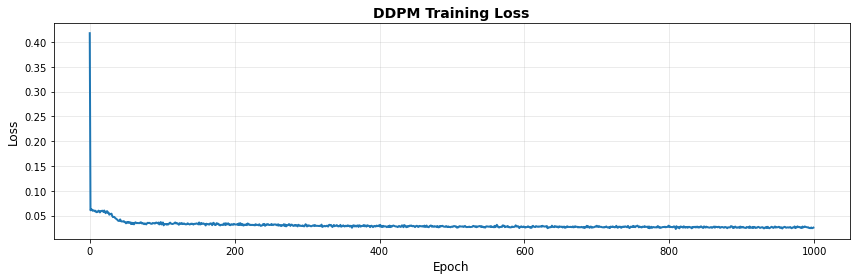

In [11]:
# Plot training loss
plt.figure(figsize=(12, 4))
plt.plot(losses, linewidth=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.title('DDPM Training Loss', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Generate Samples from Diffusion Model with Varying Sample Sizes

In [12]:
# Define sample sizes to test
sample_sizes = list(range(100, 1000, 100)) + list(range(1000, 10001, 500))

# Number of replications for each sample size
num_replications = 200

print(f"Testing {len(sample_sizes)} sample sizes: {sample_sizes}")
print(f"Running {num_replications} replications for each sample size")
print(f"Total experiments: {len(sample_sizes) * num_replications}")

Testing 28 sample sizes: [100, 200, 300, 400, 500, 600, 700, 800, 900, 1000, 1500, 2000, 2500, 3000, 3500, 4000, 4500, 5000, 5500, 6000, 6500, 7000, 7500, 8000, 8500, 9000, 9500, 10000]
Running 200 replications for each sample size
Total experiments: 5600


In [13]:
# Storage for results
results = {
    'sample_size': [],
    'cond_n_median': [],
    'cond_n_q25': [],
    'cond_n_q75': [],
    'cond_n_mean': [],
    'cond_n_std': [],
    'ratio_median': [],  # This will be used for power law analysis
    'ratio_q25': [],
    'ratio_q75': [],
    'ratio_mean': [],
    'ratio_std': []
}

# Run the experiment with optimized batch generation
print("Generating samples from DDPM and computing condition numbers...")
print("Using optimized batch generation for speed...\n")

for n in tqdm(sample_sizes, desc="Sample sizes"):
    # OPTIMIZATION: Generate all replications at once (much faster!)
    # Instead of calling ddpm.sample() 200 times, call it once with n*200 samples
    total_samples_needed = n * num_replications
    
    print(f"\n  Generating {total_samples_needed} samples ({num_replications} batches of {n})...")
    all_generated_samples = ddpm.sample(model, total_samples_needed, input_dim=input_dimension).cpu().numpy()
    
    # Storage for replications
    cond_n_replications = []
    ratio_replications = []
    
    # Split the generated samples into replications
    print(f"  Computing condition numbers for {num_replications} replications...")
    for r in range(num_replications):
        # Extract samples for this replication
        start_idx = r * n
        end_idx = (r + 1) * n
        generated_samples = all_generated_samples[start_idx:end_idx]
        
        # Compute sample covariance matrix
        sample_cov = pd.DataFrame(generated_samples).cov().values
        
        # Compute condition number of sample covariance
        cond_n = np.linalg.cond(sample_cov)
        
        # Compute ratio
        ratio = cond_n / cond_0
        
        # Store replication results
        cond_n_replications.append(cond_n)
        ratio_replications.append(ratio)
    
    # Compute statistics across replications
    results['sample_size'].append(n)
    results['cond_n_median'].append(np.median(cond_n_replications))
    results['cond_n_q25'].append(np.percentile(cond_n_replications, 25))
    results['cond_n_q75'].append(np.percentile(cond_n_replications, 75))
    results['cond_n_mean'].append(np.mean(cond_n_replications))
    results['cond_n_std'].append(np.std(cond_n_replications))
    
    results['ratio_median'].append(np.median(ratio_replications))
    results['ratio_q25'].append(np.percentile(ratio_replications, 25))
    results['ratio_q75'].append(np.percentile(ratio_replications, 75))
    results['ratio_mean'].append(np.mean(ratio_replications))
    results['ratio_std'].append(np.std(ratio_replications))

# Convert to DataFrame for easier analysis
results_df = pd.DataFrame(results)
print("\n" + "="*60)
print("SAMPLING COMPLETE")
print("="*60)
print("\nFirst few results:")
print(results_df[['sample_size', 'cond_n_median', 'ratio_median', 'ratio_q25', 'ratio_q75']].head())
print("\nLast few results:")
print(results_df[['sample_size', 'cond_n_median', 'ratio_median', 'ratio_q25', 'ratio_q75']].tail())

Generating samples from DDPM and computing condition numbers...
Using optimized batch generation for speed...



Sample sizes:   0%|          | 0/28 [00:00<?, ?it/s]


  Generating 20000 samples (200 batches of 100)...



Sampling: 0it [00:00, ?it/s]
Sampling: 165it [00:00, 1649.28it/s]
Sampling: 367it [00:00, 1865.08it/s]
Sampling: 574it [00:00, 1955.49it/s]
Sampling: 783it [00:00, 2005.40it/s]
Sampling: 994it [00:00, 2040.69it/s]
Sampling: 1205it [00:00, 2062.41it/s]
Sampling: 1417it [00:00, 2078.28it/s]
Sampling: 1628it [00:00, 2086.82it/s]
Sampling: 1840it [00:00, 2096.00it/s]
Sampling: 2051it [00:01, 2099.84it/s]
Sampling: 2264it [00:01, 2107.92it/s]
Sampling: 2476it [00:01, 2110.91it/s]
Sampling: 2688it [00:01, 2112.83it/s]
Sampling: 2901it [00:01, 2116.99it/s]
Sampling: 3115it [00:01, 2122.14it/s]
Sampling: 3328it [00:01, 2123.69it/s]
Sampling: 3542it [00:01, 2126.21it/s]
Sampling: 3756it [00:01, 2128.64it/s]
Sampling: 4000it [00:01, 2083.84it/s]
Sample sizes:   4%|▎         | 1/28 [00:01<00:53,  1.98s/it]

  Computing condition numbers for 200 replications...

  Generating 40000 samples (200 batches of 200)...


...


  Generating 2000000 samples (200 batches of 10000)...



Sampling: 0it [00:00, ?it/s]
Sampling: 1it [00:00,  2.43it/s]
Sampling: 8it [00:00, 19.67it/s]
Sampling: 15it [00:00, 32.46it/s]
Sampling: 22it [00:00, 41.82it/s]
Sampling: 29it [00:00, 48.56it/s]
Sampling: 36it [00:00, 53.39it/s]
Sampling: 43it [00:01, 56.85it/s]
Sampling: 50it [00:01, 59.28it/s]
Sampling: 57it [00:01, 61.00it/s]
Sampling: 64it [00:01, 62.20it/s]
Sampling: 71it [00:01, 63.00it/s]
Sampling: 78it [00:01, 63.61it/s]
Sampling: 85it [00:01, 64.04it/s]
Sampling: 92it [00:01, 64.33it/s]
Sampling: 99it [00:01, 64.55it/s]
Sampling: 106it [00:02, 64.69it/s]
Sampling: 113it [00:02, 64.78it/s]
Sampling: 120it [00:02, 64.85it/s]
Sampling: 127it [00:02, 64.83it/s]
Sampling: 134it [00:02, 64.91it/s]
Sampling: 141it [00:02, 64.93it/s]
Sampling: 148it [00:02, 64.98it/s]
Sampling: 155it [00:02, 64.99it/s]
Sampling: 162it [00:02, 65.01it/s]
Sampling: 169it [00:02, 65.01it/s]
Sampling: 176it [00:03, 65.01it/s]
Sampling: 183it [00:03, 65.01it/s]
Sampling: 190it [00:03, 65.02it/s]
Samplin

  Computing condition numbers for 200 replications...


Sample sizes: 100%|██████████| 28/28 [11:46<00:00, 25.24s/it]


SAMPLING COMPLETE

First few results:
   sample_size  cond_n_median  ratio_median  ratio_q25  ratio_q75
0          100     247.847523      2.723264   2.411206   3.090018
1          200     101.759964      1.118104   1.013189   1.205554
2          300      79.091352      0.869029   0.813523   0.934446
3          400      70.413370      0.773678   0.732659   0.822659
4          500      66.487543      0.730543   0.692238   0.768610

Last few results:
    sample_size  cond_n_median  ratio_median  ratio_q25  ratio_q75
23         8000      51.880714      0.570048   0.560711   0.579613
24         8500      51.903059      0.570293   0.561517   0.580063
25         9000      51.663164      0.567657   0.558576   0.576167
26         9500      51.750122      0.568613   0.562329   0.576106
27        10000      51.823752      0.569422   0.560489   0.577322


## 5. Visualize the Results

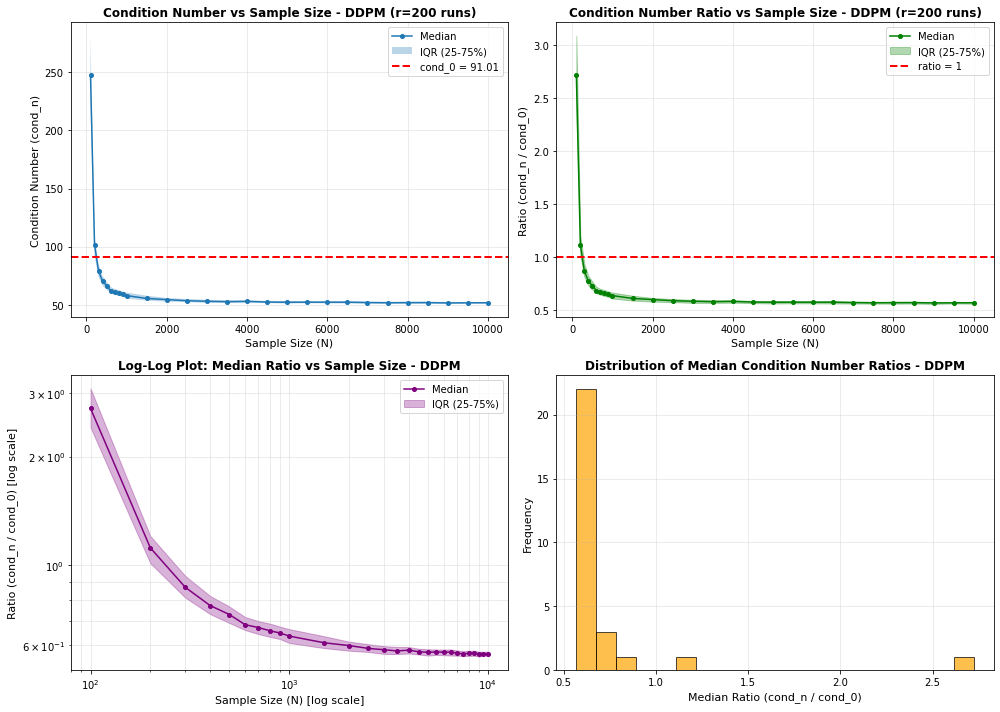

In [14]:
# Plot the condition numbers with median and quartiles
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: cond_n vs sample size (with quartiles)
axes[0, 0].plot(results_df['sample_size'].values, results_df['cond_n_median'].values, 'o-', markersize=4, label='Median')
axes[0, 0].fill_between(results_df['sample_size'], 
                         results_df['cond_n_q25'], 
                         results_df['cond_n_q75'], 
                         alpha=0.3, label='IQR (25-75%)')
axes[0, 0].axhline(y=cond_0, color='r', linestyle='--', label=f'cond_0 = {cond_0:.2f}', linewidth=2)
axes[0, 0].set_xlabel('Sample Size (N)', fontsize=11)
axes[0, 0].set_ylabel('Condition Number (cond_n)', fontsize=11)
axes[0, 0].set_title(f'Condition Number vs Sample Size - DDPM (r={num_replications} runs)', fontsize=12, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Ratio (cond_n / cond_0) vs sample size (with quartiles)
axes[0, 1].plot(results_df['sample_size'].values, results_df['ratio_median'].values, 'o-', markersize=4, color='green', label='Median')
axes[0, 1].fill_between(results_df['sample_size'], 
                         results_df['ratio_q25'], 
                         results_df['ratio_q75'], 
                         alpha=0.3, color='green', label='IQR (25-75%)')
axes[0, 1].axhline(y=1, color='r', linestyle='--', label='ratio = 1', linewidth=2)
axes[0, 1].set_xlabel('Sample Size (N)', fontsize=11)
axes[0, 1].set_ylabel('Ratio (cond_n / cond_0)', fontsize=11)
axes[0, 1].set_title(f'Condition Number Ratio vs Sample Size - DDPM (r={num_replications} runs)', fontsize=12, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Log-log plot (for power law detection)
axes[1, 0].loglog(results_df['sample_size'].values, results_df['ratio_median'].values, 'o-', markersize=4, color='purple', label='Median')
axes[1, 0].fill_between(results_df['sample_size'], 
                         results_df['ratio_q25'], 
                         results_df['ratio_q75'], 
                         alpha=0.3, color='purple', label='IQR (25-75%)')
axes[1, 0].set_xlabel('Sample Size (N) [log scale]', fontsize=11)
axes[1, 0].set_ylabel('Ratio (cond_n / cond_0) [log scale]', fontsize=11)
axes[1, 0].set_title('Log-Log Plot: Median Ratio vs Sample Size - DDPM', fontsize=12, fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3, which='both')

# Plot 4: Distribution of median ratios
axes[1, 1].hist(results_df['ratio_median'].values, bins=20, edgecolor='black', alpha=0.7, color='orange')
axes[1, 1].set_xlabel('Median Ratio (cond_n / cond_0)', fontsize=11)
axes[1, 1].set_ylabel('Frequency', fontsize=11)
axes[1, 1].set_title('Distribution of Median Condition Number Ratios - DDPM', fontsize=12, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Power Law Analysis

In [15]:
# Fit a power law: ratio_median = a * N^b
# Taking log: log(ratio_median) = log(a) + b * log(N)

from scipy.optimize import curve_fit

def power_law(x, a, b):
    return a * np.power(x, b)

# Fit the power law using median values
params, covariance = curve_fit(
    power_law,
    results_df['sample_size'],
    results_df['ratio_median'],
    p0=[1, -0.5]  # Initial guess: ratio decreases with sample size
)

a_fit, b_fit = params
print(f"\nPower Law Fit (using median across {num_replications} runs):")
print(f"  ratio_median = {a_fit:.4f} * N^{b_fit:.4f}")
print(f"\nParameter uncertainties:")
print(f"  a: {np.sqrt(covariance[0, 0]):.4f}")
print(f"  b: {np.sqrt(covariance[1, 1]):.4f}")


Power Law Fit (using median across 200 runs):
  ratio_median = 9.5183 * N^-0.3586

Parameter uncertainties:
  a: 3.0075
  b: 0.0491


In [16]:
# Compute R-squared to assess fit quality
fitted_values = power_law(results_df['sample_size'], a_fit, b_fit)
residuals = results_df['ratio_median'] - fitted_values
ss_res = np.sum(residuals**2)
ss_tot = np.sum((results_df['ratio_median'] - np.mean(results_df['ratio_median']))**2)
r_squared = 1 - (ss_res / ss_tot)

print(f"\nGoodness of Fit:")
print(f"  R-squared: {r_squared:.4f}")
print(f"  RMSE: {np.sqrt(np.mean(residuals**2)):.4f}")


Goodness of Fit:
  R-squared: 0.5938
  RMSE: 0.2578


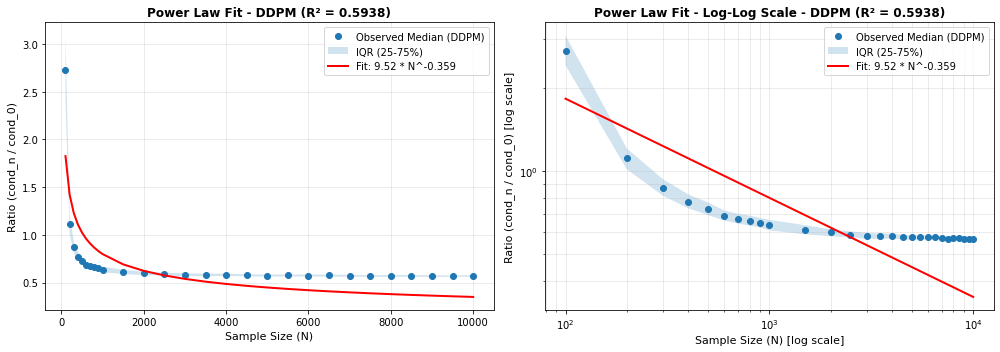

In [17]:
# Visualize the fit
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Linear scale
axes[0].plot(results_df['sample_size'].values, results_df['ratio_median'].values, 'o', label='Observed Median (DDPM)', markersize=6)
axes[0].fill_between(results_df['sample_size'], 
                      results_df['ratio_q25'], 
                      results_df['ratio_q75'], 
                      alpha=0.2, label='IQR (25-75%)')
axes[0].plot(results_df['sample_size'].values, fitted_values.values, '-', label=f'Fit: {a_fit:.2f} * N^{b_fit:.3f}', linewidth=2, color='red')
axes[0].set_xlabel('Sample Size (N)', fontsize=11)
axes[0].set_ylabel('Ratio (cond_n / cond_0)', fontsize=11)
axes[0].set_title(f'Power Law Fit - DDPM (R² = {r_squared:.4f})', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Log-log scale
axes[1].loglog(results_df['sample_size'].values, results_df['ratio_median'].values, 'o', label='Observed Median (DDPM)', markersize=6)
axes[1].fill_between(results_df['sample_size'], 
                      results_df['ratio_q25'], 
                      results_df['ratio_q75'], 
                      alpha=0.2, label='IQR (25-75%)')
axes[1].loglog(results_df['sample_size'].values, fitted_values.values, '-', 
               label=f'Fit: {a_fit:.2f} * N^{b_fit:.3f}', linewidth=2, color='red')
axes[1].set_xlabel('Sample Size (N) [log scale]', fontsize=11)
axes[1].set_ylabel('Ratio (cond_n / cond_0) [log scale]', fontsize=11)
axes[1].set_title(f'Power Law Fit - Log-Log Scale - DDPM (R² = {r_squared:.4f})', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3, which='both')

plt.tight_layout()
plt.show()

## 7. Statistical Tests for Power Law

In [18]:
# Linear regression on log-transformed data (using median values)
log_N = np.log(results_df['sample_size'])
log_ratio_median = np.log(results_df['ratio_median'])

# Perform linear regression
from scipy.stats import linregress

slope, intercept, r_value, p_value, std_err = linregress(log_N, log_ratio_median)

print("="*60)
print("LINEAR REGRESSION ON LOG-TRANSFORMED DATA")
print("="*60)
print(f"Using median ratios across {num_replications} replications\n")
print(f"  log(ratio_median) = {intercept:.4f} + {slope:.4f} * log(N)")
print(f"  Which implies: ratio_median = {np.exp(intercept):.4f} * N^{slope:.4f}")
print(f"\n  R-squared: {r_value**2:.4f}")
print(f"  p-value: {p_value:.6f}")
print(f"  Standard error: {std_err:.4f}")

if p_value < 0.001:
    print(f"\n✓ The relationship is highly significant (p < 0.001)")
elif p_value < 0.05:
    print(f"\n✓ The relationship is significant (p < 0.05)")
else:
    print(f"\n✗ The relationship is not significant (p >= 0.05)")

LINEAR REGRESSION ON LOG-TRANSFORMED DATA
Using median ratios across 200 replications

  log(ratio_median) = 1.0055 + -0.1849 * log(N)
  Which implies: ratio_median = 2.7332 * N^-0.1849

  R-squared: 0.5973
  p-value: 0.000001
  Standard error: 0.0298

✓ The relationship is highly significant (p < 0.001)


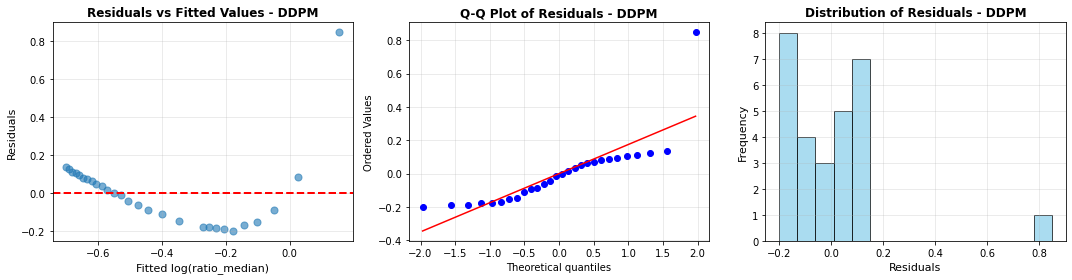

In [19]:
# Residual analysis
log_fitted = intercept + slope * log_N
log_residuals = log_ratio_median - log_fitted

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Residuals vs fitted
axes[0].scatter(log_fitted, log_residuals, alpha=0.6, s=50)
axes[0].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[0].set_xlabel('Fitted log(ratio_median)', fontsize=11)
axes[0].set_ylabel('Residuals', fontsize=11)
axes[0].set_title('Residuals vs Fitted Values - DDPM', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Q-Q plot
stats.probplot(log_residuals, dist="norm", plot=axes[1])
axes[1].set_title('Q-Q Plot of Residuals - DDPM', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)

# Histogram of residuals
axes[2].hist(log_residuals, bins=15, edgecolor='black', alpha=0.7, color='skyblue')
axes[2].set_xlabel('Residuals', fontsize=11)
axes[2].set_ylabel('Frequency', fontsize=11)
axes[2].set_title('Distribution of Residuals - DDPM', fontsize=12, fontweight='bold')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Comparison: DDPM vs Training Data

In [21]:
# Compute condition number of training data covariance
training_cov = pd.DataFrame(training_data).cov().values
training_cond = np.linalg.cond(training_cov)
training_ratio = training_cond / cond_0

print("="*60)
print("COMPARISON: DDPM SAMPLES vs TRAINING DATA")
print("="*60)
print(f"\nTraining data (N={number_training_samples}):")
print(f"  Condition number: {training_cond:.4f}")
print(f"  Ratio (cond/cond_0): {training_ratio:.4f}")
print(f"\nDDPM samples at N={number_training_samples} (if available):")
if number_training_samples in results_df['sample_size'].values:
    ddpm_row = results_df[results_df['sample_size'] == number_training_samples].iloc[0]
    print(f"  Condition number: {ddpm_row['cond_n_median']:.4f}")
    print(f"  Ratio (cond/cond_0): {ddpm_row['ratio_median']:.4f}")
    print(f"\nDifference:")
    print(f"  DDPM ratio / Training ratio = {ddpm_row['ratio_median'] / training_ratio:.4f}")
else:
    print(f"  Not tested at exactly N={number_training_samples}")
    # Find closest sample size
    closest_idx = np.argmin(np.abs(results_df['sample_size'] - number_training_samples))
    closest_row = results_df.iloc[closest_idx]
    print(f"  Closest tested: N={closest_row['sample_size']}")
    print(f"    Condition number: {closest_row['cond_n_median']:.4f}")
    print(f"    Ratio (cond/cond_0): {closest_row['ratio_median']:.4f}")

COMPARISON: DDPM SAMPLES vs TRAINING DATA

Training data (N=10000):
  Condition number: 93.8085
  Ratio (cond/cond_0): 1.0307

DDPM samples at N=10000 (if available):
  Condition number: 51.8238
  Ratio (cond/cond_0): 0.5694

Difference:
  DDPM ratio / Training ratio = 0.5524


## 9. Summary Statistics

In [22]:
print("="*60)
print("SUMMARY OF RESULTS")
print("="*60)
print(f"\nTrue covariance condition number (cond_0): {cond_0:.4f}")
print(f"\nTraining:")
print(f"  Number of samples: {number_training_samples}")
print(f"  Number of epochs: 1000")
print(f"  Final training loss: {losses[-1]:.6f}")
print(f"\nExperimental Design:")
print(f"  Number of sample sizes tested: {len(sample_sizes)}")
print(f"  Sample size range: {min(sample_sizes)} to {max(sample_sizes)}")
print(f"  Replications per sample size: {num_replications}")
print(f"  Total experiments: {len(sample_sizes) * num_replications}")
print(f"\nCondition number statistics (median across replications):")
print(f"  Min: {results_df['cond_n_median'].min():.4f}")
print(f"  Max: {results_df['cond_n_median'].max():.4f}")
print(f"  Mean: {results_df['cond_n_median'].mean():.4f}")
print(f"  Std: {results_df['cond_n_median'].std():.4f}")
print(f"\nRatio statistics (median cond_n / cond_0):")
print(f"  Min: {results_df['ratio_median'].min():.4f}")
print(f"  Max: {results_df['ratio_median'].max():.4f}")
print(f"  Mean: {results_df['ratio_median'].mean():.4f}")
print(f"  Std: {results_df['ratio_median'].std():.4f}")
print(f"\nVariability across replications (average IQR):")
print(f"  Avg IQR for cond_n: {(results_df['cond_n_q75'] - results_df['cond_n_q25']).mean():.4f}")
print(f"  Avg IQR for ratio: {(results_df['ratio_q75'] - results_df['ratio_q25']).mean():.4f}")
print(f"\nPower Law Fit Results (on median values):")
print(f"  Formula: ratio_median = {a_fit:.4f} * N^{b_fit:.4f}")
print(f"  R-squared: {r_squared:.4f}")
print(f"  Exponent (b): {b_fit:.4f} ± {np.sqrt(covariance[1, 1]):.4f}")
print(f"\nLinear Regression on Log-Transformed Data:")
print(f"  Formula: ratio_median ≈ {np.exp(intercept):.4f} * N^{slope:.4f}")
print(f"  R-squared: {r_value**2:.4f}")
print(f"  p-value: {p_value:.6f}")

# Interpretation
print(f"\n" + "="*60)
print("INTERPRETATION")
print("="*60)
if r_squared > 0.9:
    print("✓ The data shows a STRONG power law relationship")
elif r_squared > 0.7:
    print("✓ The data shows a MODERATE power law relationship")
else:
    print("✗ The data shows a WEAK power law relationship")

if b_fit < 0:
    print(f"✓ The ratio DECREASES as sample size increases (exponent = {b_fit:.4f})")
    print(f"  This means DDPM-generated samples become relatively better conditioned with more samples")
else:
    print(f"✗ The ratio INCREASES as sample size increases (exponent = {b_fit:.4f})")
    print(f"  This means DDPM-generated samples become relatively worse conditioned with more samples")

# Compare with true covariance
avg_ratio = results_df['ratio_median'].mean()
if avg_ratio < 1:
    print(f"\n✓ On average, DDPM samples have BETTER conditioning than the true covariance")
    print(f"  Average ratio: {avg_ratio:.4f} (< 1)")
elif avg_ratio > 1:
    print(f"\n✗ On average, DDPM samples have WORSE conditioning than the true covariance")
    print(f"  Average ratio: {avg_ratio:.4f} (> 1)")
else:
    print(f"\n≈ On average, DDPM samples have SIMILAR conditioning to the true covariance")
    print(f"  Average ratio: {avg_ratio:.4f} (≈ 1)")

# Convergence analysis
if results_df['ratio_median'].iloc[-1] < 1.1 and results_df['ratio_median'].iloc[-1] > 0.9:
    print(f"\n✓ The ratio converges to approximately 1 at large N (N={max(sample_sizes)})")
    print(f"  Final ratio: {results_df['ratio_median'].iloc[-1]:.4f}")
else:
    print(f"\n✗ The ratio does not converge to 1 at N={max(sample_sizes)}")
    print(f"  Final ratio: {results_df['ratio_median'].iloc[-1]:.4f}")

SUMMARY OF RESULTS

True covariance condition number (cond_0): 91.0112

Training:
  Number of samples: 10000
  Number of epochs: 1000
  Final training loss: 0.025654

Experimental Design:
  Number of sample sizes tested: 28
  Sample size range: 100 to 10000
  Replications per sample size: 200
  Total experiments: 5600

Condition number statistics (median across replications):
  Min: 51.6632
  Max: 247.8475
  Mean: 64.7454
  Std: 37.4813

Ratio statistics (median cond_n / cond_0):
  Min: 0.5677
  Max: 2.7233
  Mean: 0.7114
  Std: 0.4118

Variability across replications (average IQR):
  Avg IQR for cond_n: 6.0304
  Avg IQR for ratio: 0.0663

Power Law Fit Results (on median values):
  Formula: ratio_median = 9.5183 * N^-0.3586
  R-squared: 0.5938
  Exponent (b): -0.3586 ± 0.0491

Linear Regression on Log-Transformed Data:
  Formula: ratio_median ≈ 2.7332 * N^-0.1849
  R-squared: 0.5973
  p-value: 0.000001

INTERPRETATION
✗ The data shows a WEAK power law relationship
✓ The ratio DECREASE

In [23]:
# Save results with all statistics
results_df.to_csv('diffusion_condition_number_results.csv', index=False)
print("\n" + "="*60)
print("Results saved to 'diffusion_condition_number_results.csv'")
print("="*60)
print("\nSaved columns:")
print("  - sample_size: Number of samples generated from DDPM")
print("  - cond_n_median: Median condition number across replications")
print("  - cond_n_q25: 25th percentile of condition numbers")
print("  - cond_n_q75: 75th percentile of condition numbers")
print("  - cond_n_mean: Mean condition number across replications")
print("  - cond_n_std: Standard deviation of condition numbers")
print("  - ratio_median: Median of cond_n/cond_0 (used for power law)")
print("  - ratio_q25: 25th percentile of ratios")
print("  - ratio_q75: 75th percentile of ratios")
print("  - ratio_mean: Mean of ratios")
print("  - ratio_std: Standard deviation of ratios")


Results saved to 'diffusion_condition_number_results.csv'

Saved columns:
  - sample_size: Number of samples generated from DDPM
  - cond_n_median: Median condition number across replications
  - cond_n_q25: 25th percentile of condition numbers
  - cond_n_q75: 75th percentile of condition numbers
  - cond_n_mean: Mean condition number across replications
  - cond_n_std: Standard deviation of condition numbers
  - ratio_median: Median of cond_n/cond_0 (used for power law)
  - ratio_q25: 25th percentile of ratios
  - ratio_q75: 75th percentile of ratios
  - ratio_mean: Mean of ratios
  - ratio_std: Standard deviation of ratios


## 10. Additional Analysis: Quality Check

Generating 5000 samples for quality check...


Sampling: 4000it [00:01, 2178.79it/s]


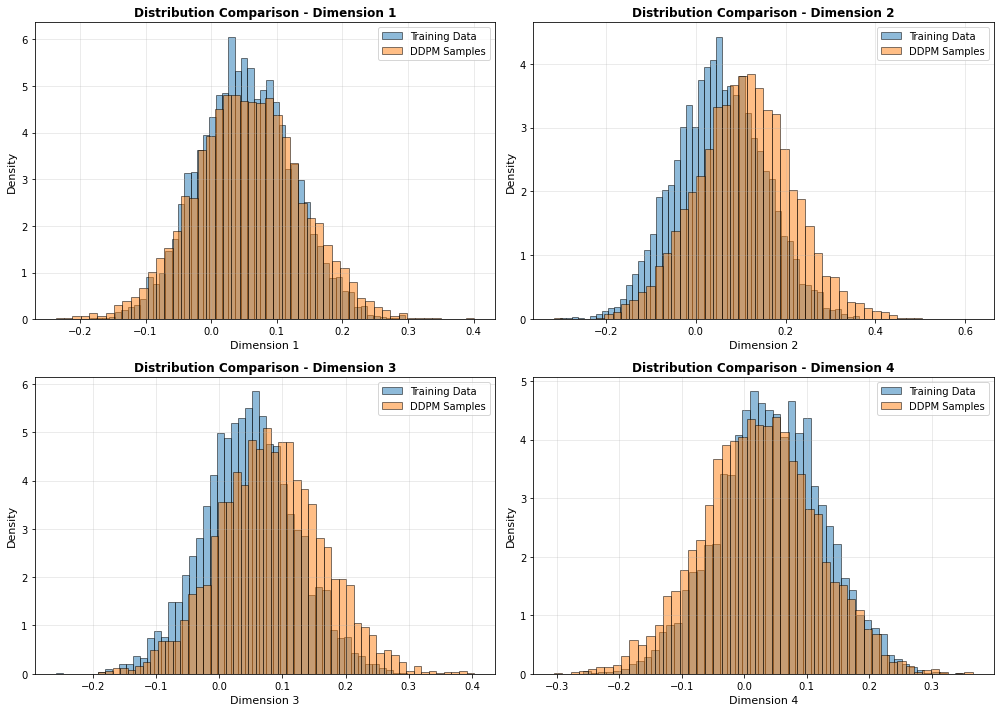


Mean comparison (first 5 dimensions):
  Training data: [0.05180526 0.05244087 0.04782886 0.04237191 0.06300768]
  DDPM samples:  [0.05559554 0.10837746 0.08214993 0.02404365 0.04277549]

Std comparison (first 5 dimensions):
  Training data: [0.07075646 0.09809433 0.07347683 0.0841678  0.10723661]
  DDPM samples:  [0.08178702 0.10864785 0.08318888 0.09161798 0.11410921]


In [24]:
# Generate a large sample for quality check
print("Generating 5000 samples for quality check...")
large_sample = ddpm.sample(model, 5000, input_dim=input_dimension).cpu().numpy()

# Compare distributions
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Compare marginal distributions for first few dimensions
for i in range(4):
    row = i // 2
    col = i % 2
    
    axes[row, col].hist(training_data[:5000, i], bins=50, alpha=0.5, label='Training Data', 
                        density=True, edgecolor='black')
    axes[row, col].hist(large_sample[:, i], bins=50, alpha=0.5, label='DDPM Samples', 
                        density=True, edgecolor='black')
    axes[row, col].set_xlabel(f'Dimension {i+1}', fontsize=11)
    axes[row, col].set_ylabel('Density', fontsize=11)
    axes[row, col].set_title(f'Distribution Comparison - Dimension {i+1}', 
                             fontsize=12, fontweight='bold')
    axes[row, col].legend()
    axes[row, col].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nMean comparison (first 5 dimensions):")
print(f"  Training data: {training_data[:5000, :5].mean(axis=0)}")
print(f"  DDPM samples:  {large_sample[:, :5].mean(axis=0)}")
print(f"\nStd comparison (first 5 dimensions):")
print(f"  Training data: {training_data[:5000, :5].std(axis=0)}")
print(f"  DDPM samples:  {large_sample[:, :5].std(axis=0)}")